In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gymnasium as gym
import os

import numpy as np
from tensorboard.backend.event_processing import event_accumulator
from pathlib import Path
from stable_baselines3 import PPO as SB3PPO
from highway.scripts.run import eval_agent, run_one_episode
from highway.scripts.environment import get_env, ConfigType
from highway.scripts.utils.agents import SB3GreedyAgent
from highway.scripts.utils.plotting import (
    plot_losses,
    plot_rewards_lengths,
    plot_train_rewards_lengths,
)
from highway.scripts.utils.save_gif import save_gif
from highway.scripts.utils.statistics import compute_confidence_interval

In [3]:
OUTPUT_ROOT = Path("outputs_cnn_ppo_3")
EVAL_CURVES_PATH = OUTPUT_ROOT / "eval_curves.npz"
EVAL_LOGS_PATH = OUTPUT_ROOT / "eval_logs" / "evaluations.npz"
BEST_MODEL_PATH = OUTPUT_ROOT / "best_model" / "best_model.zip"
REF_BEST_MODEL_PATH = OUTPUT_ROOT / "REF_BEST.zip"
FINAL_MODEL_PATH = OUTPUT_ROOT / "model.zip"
TB_ROOT = OUTPUT_ROOT / "tb"
EVENT_PATH = TB_ROOT / "ppo_cnn_20260414_035552_1"/"ppo_cnn_20260414_035552_1.0"
eval_data = np.load(EVAL_CURVES_PATH)
timesteps = eval_data["timesteps"]
mean_rewards = eval_data["mean_rewards"]
mean_ep_lengths = eval_data["mean_ep_lengths"]

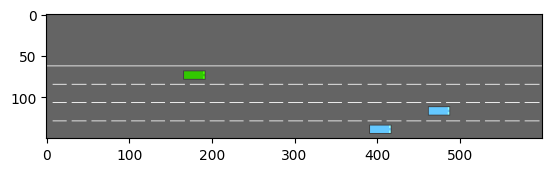

Episode reward=20.86, length=30


In [5]:
sb3_model = SB3PPO.load(
    str(BEST_MODEL_PATH),
    device="cpu",
    custom_objects={"buffer_size": 1},
)
should_save = True
seed = 4 
agent = SB3GreedyAgent(sb3_model)
env_CNN = get_env(config_type=ConfigType.TEST_CNN)
reward, length = run_one_episode(seed=seed, env=env_CNN, agent=agent, display=True, make_deep_copy=False)

if should_save:
    save_gif(env_CNN, agent, path="cnn-dqn-agent.gif", seed=seed, make_deep_copy=False)

In [27]:
eval_seeds = list(range(50))
rewards, lengths = eval_agent(env_CNN, agent, seeds=eval_seeds, show_progress=True, make_deep_copy=False)

Evaluating: 100%|██████████| 50/50 [04:13<00:00,  5.06s/ep]


In [28]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 19.75 ± 1.15 (95% CI: [18.60, 20.90])
Length: 28.46 ± 1.62 (95% CI: [26.84, 30.08])


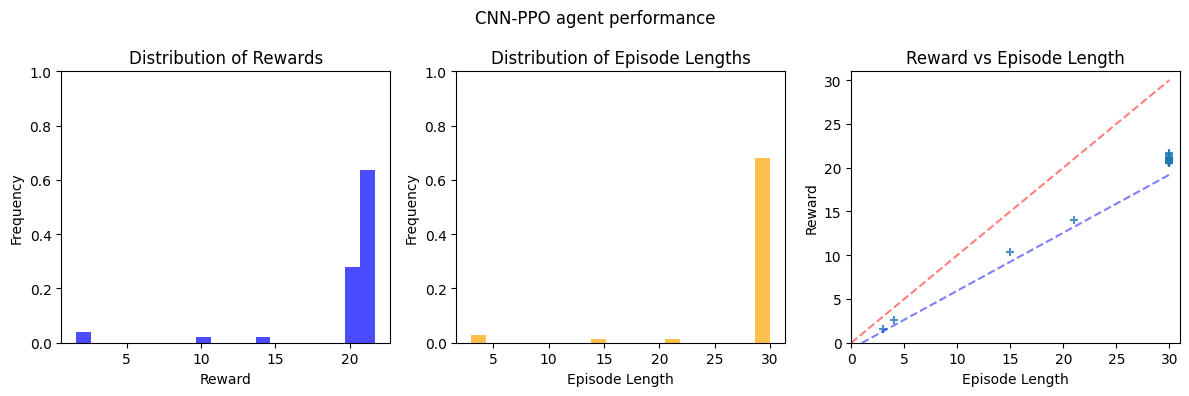

In [29]:
plot_rewards_lengths(rewards, lengths, title="CNN-PPO agent performance")

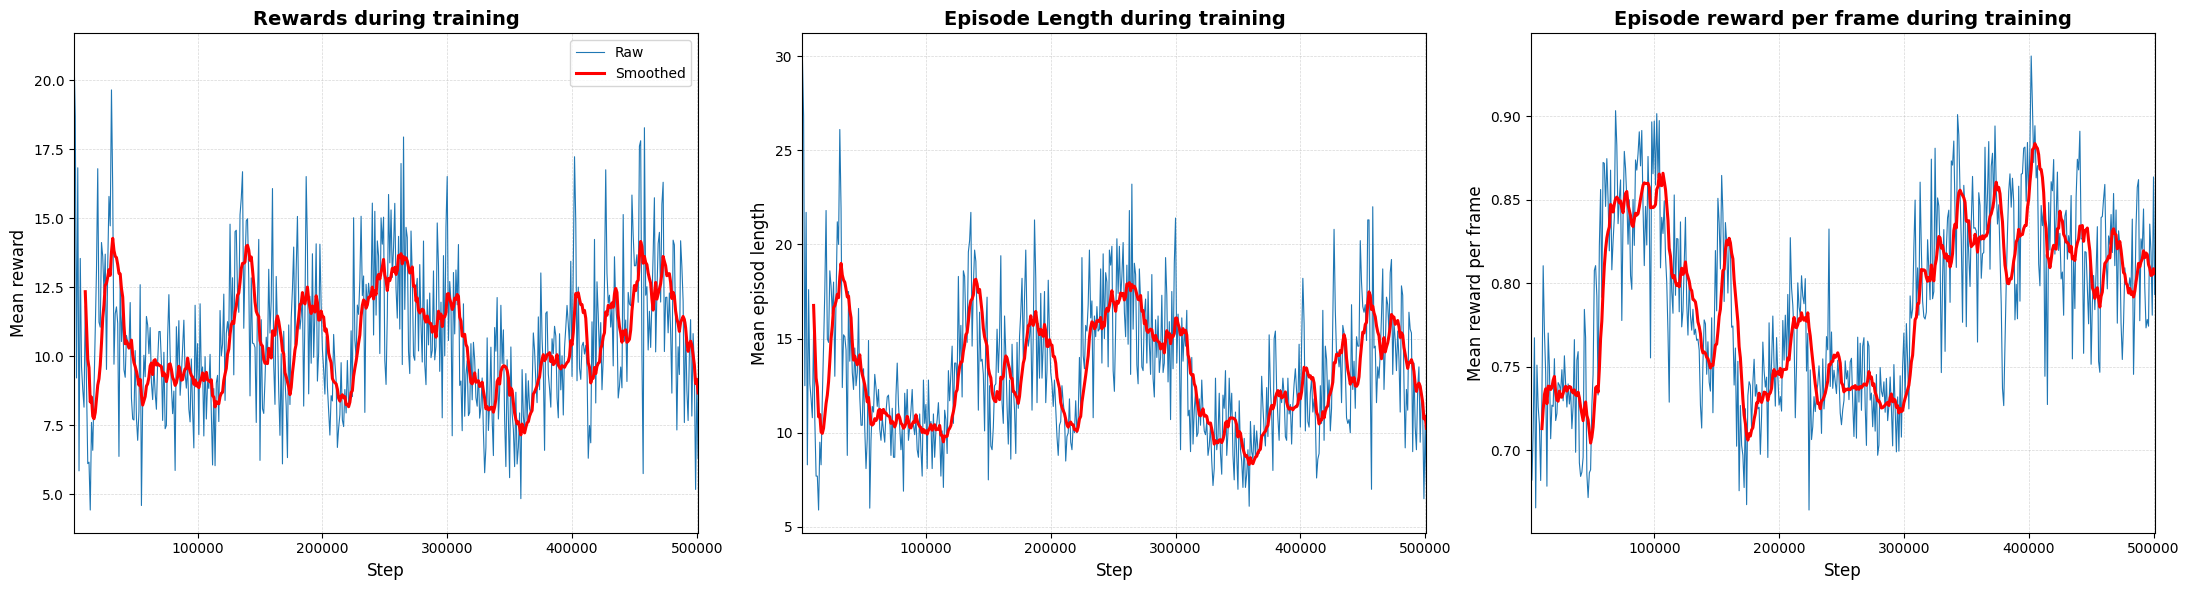

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_ROOT = Path("outputs_cnn_ppo")
EVAL_LOGS_PATH = OUTPUT_ROOT / "eval_logs" / "evaluations.npz"

if not EVAL_LOGS_PATH.exists():
    print(f" Fichier introuvable : {EVAL_LOGS_PATH}")
else:
    data = np.load(EVAL_LOGS_PATH)
    results = data['results']      
    timesteps = data['timesteps']
    ep_lengths = data['ep_lengths'] 

    mean_rewards = np.mean(results, axis=1)
    mean_lengths = np.mean(ep_lengths, axis=1)

    with np.errstate(divide='ignore', invalid='ignore'):
        rew_per_frame_raw = results / ep_lengths
        rew_per_frame_raw = np.nan_to_num(rew_per_frame_raw) 
        mean_rew_per_frame = np.mean(rew_per_frame_raw, axis=1)


    data_list = [mean_rewards, mean_lengths, mean_rew_per_frame]
    titles = ["Rewards during training", "Episode Length during training", "Episode reward per frame during training"]
    y_labels = ["Mean reward", "Mean episod length", "Mean reward per frame"]
    nb_smoothen = 10

    fig, axs = plt.subplots(1, 3, figsize=(22, 6))

    for i, (ax, d, title, y_label) in enumerate(zip(axs, data_list, titles, y_labels)):
        ax.plot(timesteps, d, color='#1f77b4', linewidth=0.8, alpha=1.0, label="Raw")

        if len(d) >= nb_smoothen:
            smooth = np.convolve(d, np.ones(nb_smoothen)/nb_smoothen, mode='valid')
            x_smooth = timesteps[nb_smoothen-1:]

            ax.plot(x_smooth, smooth, color='red', linewidth=2.2, label="Smoothed")

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel("Step", fontsize=12)
        ax.set_ylabel(y_label, fontsize=12)

        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

        ax.autoscale(enable=True, axis='x', tight=True)

        if i == 0:
            ax.legend(loc='best')

    plt.tight_layout()
    plt.show()